In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os

In [2]:
torch.manual_seed(42)

In [3]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

ModuleNotFoundError: No module named 'kagglehub'

In [ ]:
df = pd.read_csv(os.path.join(path, 'fashion-mnist_train.csv'))
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


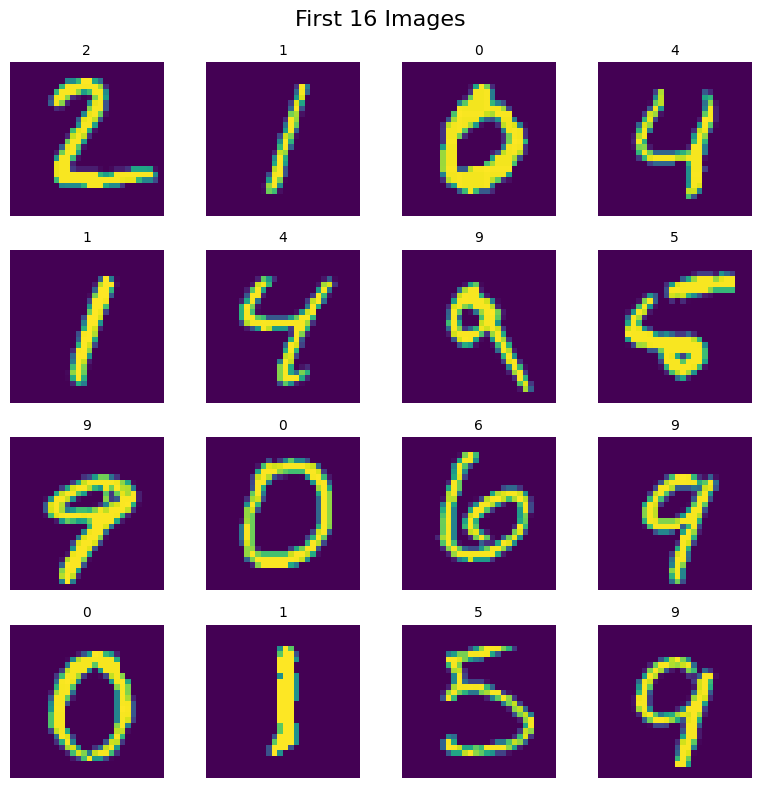

In [ ]:
import numpy as np

# If your CSV has labels in the first column and 784 pixels afterward:
imgs = df.iloc[:16, 1:].values
labels = df.iloc[:16, 0].values

imgs = imgs.reshape(-1, 28, 28)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle("First 16 Images", fontsize=16)
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[idx], cmap="viridis")
    ax.axis("off")
    ax.set_title(str(labels[idx]), fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [ ]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
batch = next(iter(train_loader))
print(batch[0].shape, batch[1].shape)

torch.Size([32, 784]) torch.Size([32])


In [ ]:
batch

[tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([4, 9, 3, 7, 0, 0, 2, 9, 2, 4, 2, 0, 6, 8, 7, 5, 7, 1, 1, 0, 2, 1, 4, 1,
         0, 4, 4, 7, 0, 1, 3, 2])]

In [ ]:
class MyANN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
epochs = 100
learning_rate = 0.001

model = MyANN(X_train.shape[1])
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
len(train_loader)

250

In [ ]:
for epoch in range(epochs):
    total_loss = 0
    for batch_features, batch_labels in train_loader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_features.float())
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch: {epoch+1}, Loss: {avg_loss:.2f}')

Epoch: 1, Loss: 0.00
Epoch: 2, Loss: 0.00
Epoch: 3, Loss: 0.00
Epoch: 4, Loss: 0.00
Epoch: 5, Loss: 0.00
Epoch: 6, Loss: 0.00
Epoch: 7, Loss: 0.00
Epoch: 8, Loss: 0.00
Epoch: 9, Loss: 0.00
Epoch: 10, Loss: 0.00
Epoch: 11, Loss: 0.00
Epoch: 12, Loss: 0.00
Epoch: 13, Loss: 0.00
Epoch: 14, Loss: 0.00
Epoch: 15, Loss: 0.00
Epoch: 16, Loss: 0.00
Epoch: 17, Loss: 0.00
Epoch: 18, Loss: 0.00
Epoch: 19, Loss: 0.00
Epoch: 20, Loss: 0.00
Epoch: 21, Loss: 0.00
Epoch: 22, Loss: 0.00
Epoch: 23, Loss: 0.00
Epoch: 24, Loss: 0.00
Epoch: 25, Loss: 0.00
Epoch: 26, Loss: 0.00
Epoch: 27, Loss: 0.00
Epoch: 28, Loss: 0.00
Epoch: 29, Loss: 0.00
Epoch: 30, Loss: 0.00
Epoch: 31, Loss: 0.00
Epoch: 32, Loss: 0.00
Epoch: 33, Loss: 0.00
Epoch: 34, Loss: 0.00
Epoch: 35, Loss: 0.00
Epoch: 36, Loss: 0.00
Epoch: 37, Loss: 0.00
Epoch: 38, Loss: 0.00
Epoch: 39, Loss: 0.13
Epoch: 40, Loss: 0.00
Epoch: 41, Loss: 0.00
Epoch: 42, Loss: 0.00
Epoch: 43, Loss: 0.00
Epoch: 44, Loss: 0.00
Epoch: 45, Loss: 0.00
Epoch: 46, Loss: 0.

In [ ]:
model.eval()

MyANN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features.float())
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.shape[0]
        correct += (predicted == batch_labels).sum().item()

    print(f'Accuracy: {correct/total:.2f}')

Accuracy: 0.96
